### Installation : **pip install scikit-learn** ( Install before USE***)

In [1]:
import sklearn
print(sklearn.__version__)

1.6.1


In [2]:
import numpy as np

## **train_test_split()** -> **Splitting dataset into training and testing data**
### It is used to divide a dataset into training data and testing data.
### Training data → Used to train the model.
### Testing data → Used to evaluate the model on unseen data.


> x -> Input Features ( always should be in 2d array)


> y -> Output/target values ( 1d array )


> test_size = 0.2 means 20% i.e 20% of 5rows


> Using random_state keeps the split fixed, making results reproducible and 42 is just a random number, any number can be used .

In [3]:
from sklearn.model_selection import train_test_split
x = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y = np.array([10,30,43,58,70,85,88,94,100,105])
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("x_train",x_train)
print("y_train",y_train)
print("x_test",x_test)
print("y_test",y_test)

x_train [[ 6]
 [ 1]
 [ 8]
 [ 3]
 [10]
 [ 5]
 [ 4]
 [ 7]]
y_train [ 85  10  94  43 105  70  58  88]
x_test [[9]
 [2]]
y_test [100  30]


### Choose Algorithm to train - LinearRegression example
### fit()     = Learn
### predict() = Guess

In [4]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
prediction = model.predict(x_test)
print(prediction)

[105.78448276  32.46551724]


## **cross_val_score()** -> **Cross Validation**
###Problem with Train-Test Split

`train_test_split(X, y, test_size=0.2)`
### 80% → Training Data
### 20% → Testing Data

## Issue:

###One test split may be too easy or too hard.
###Accuracy may change with a different split.
###Single score may not be reliable.
##Cross Validation

##Idea:

###Instead of testing once, test multiple times and take the average score.

##K-Fold Cross Validation

##Example:

###Total Rows = 100
###k = 5

##Split data into: (totalrows/k=num of rows in each fold)

###Fold 1 = 20 rows
###Fold 2 = 20 rows
###Fold 3 = 20 rows
###Fold 4 = 20 rows
###Fold 5 = 20 rows

##For each round:

###1 Fold  → Testing
###Remaining 4 Folds → Training

###Repeat 5 times.

##Final Score
###Average of all 5 scores
##Advantages

✅ More reliable than a single train-test split

✅ Uses all data for both training and testing

✅ Reduces chance of getting lucky/unlucky splits

In [5]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,x,y,cv=5)
print(scores)
print(scores.mean())

[ -2.41685445   0.62555556  -1.4490852   -0.37845079 -51.28854875]
-10.981476727350442


### cross_val_score() with LinearRegression
### uses R² Score by default.
### can also specify which metric to be used to evaluate by using scoring parameter in cross_val_score() function .
### like : cross_val_score(model,x,y,cv=5,scoring='r2')

### R² can be negative.

### Negative R² means the model performs worse than simply predicting the average target value.

### With very small datasets (like 10 rows), negative R² scores are common because each fold has too few test samples.

## **Pipeline**

### Purpose : Combine preprocessing and model into a single workflow.

## Syntax:

### Pipeline([('step1',Preprocessing),('step2',Model)])

## Example:

### Pipeline([('scaler',StandardScaler()),('model',KNeighborsClassifier())])

### Benefits: Cleaner code, Less errors, Works well with GridSearchCV

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
a = np.array([[20,20000,70],[30,30000,75],[40,35000,79]])
b = np.array([0,1,1])
pipe = Pipeline([('scaler',StandardScaler()),('model',KNeighborsClassifier(n_neighbors=1))])
pipe.fit(a,b)
prediction = pipe.predict([[15,18000,65]])
print(prediction)

[0]


## Internal Working:
### pipe.fit(x,y) -> StandardScaler.fit_transform(X) -> Scaled X -> KNeighborsClassifier.fit(Scaled X, y)

## Important:

### ✓ Only X is scaled

### ✗ y is NOT scaled

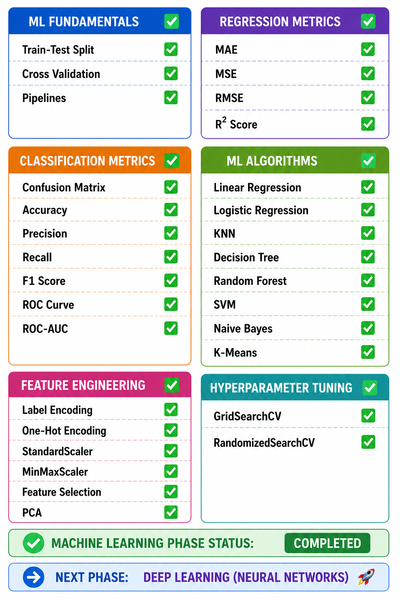